# Q8: Results

**Phase 9:** Results & Insights  
**Points: 3 points**

**Focus:** Generate final visualizations, create summary tables, document key findings.

**Lecture Reference:** Lecture 11, Notebook 4 ([`11/demo/04_modeling_results.ipynb`](https://github.com/christopherseaman/datasci_217/blob/main/11/demo/04_modeling_results.ipynb)), Phase 9. Also see Lecture 07 (visualization).

---

## Setup

In [41]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load model results from Q7
predictions = pd.read_csv('output/q7_predictions.csv')
metrics = open('output/q7_model_metrics.txt').read()
feature_importance = pd.read_csv('output/q7_feature_importance.csv')

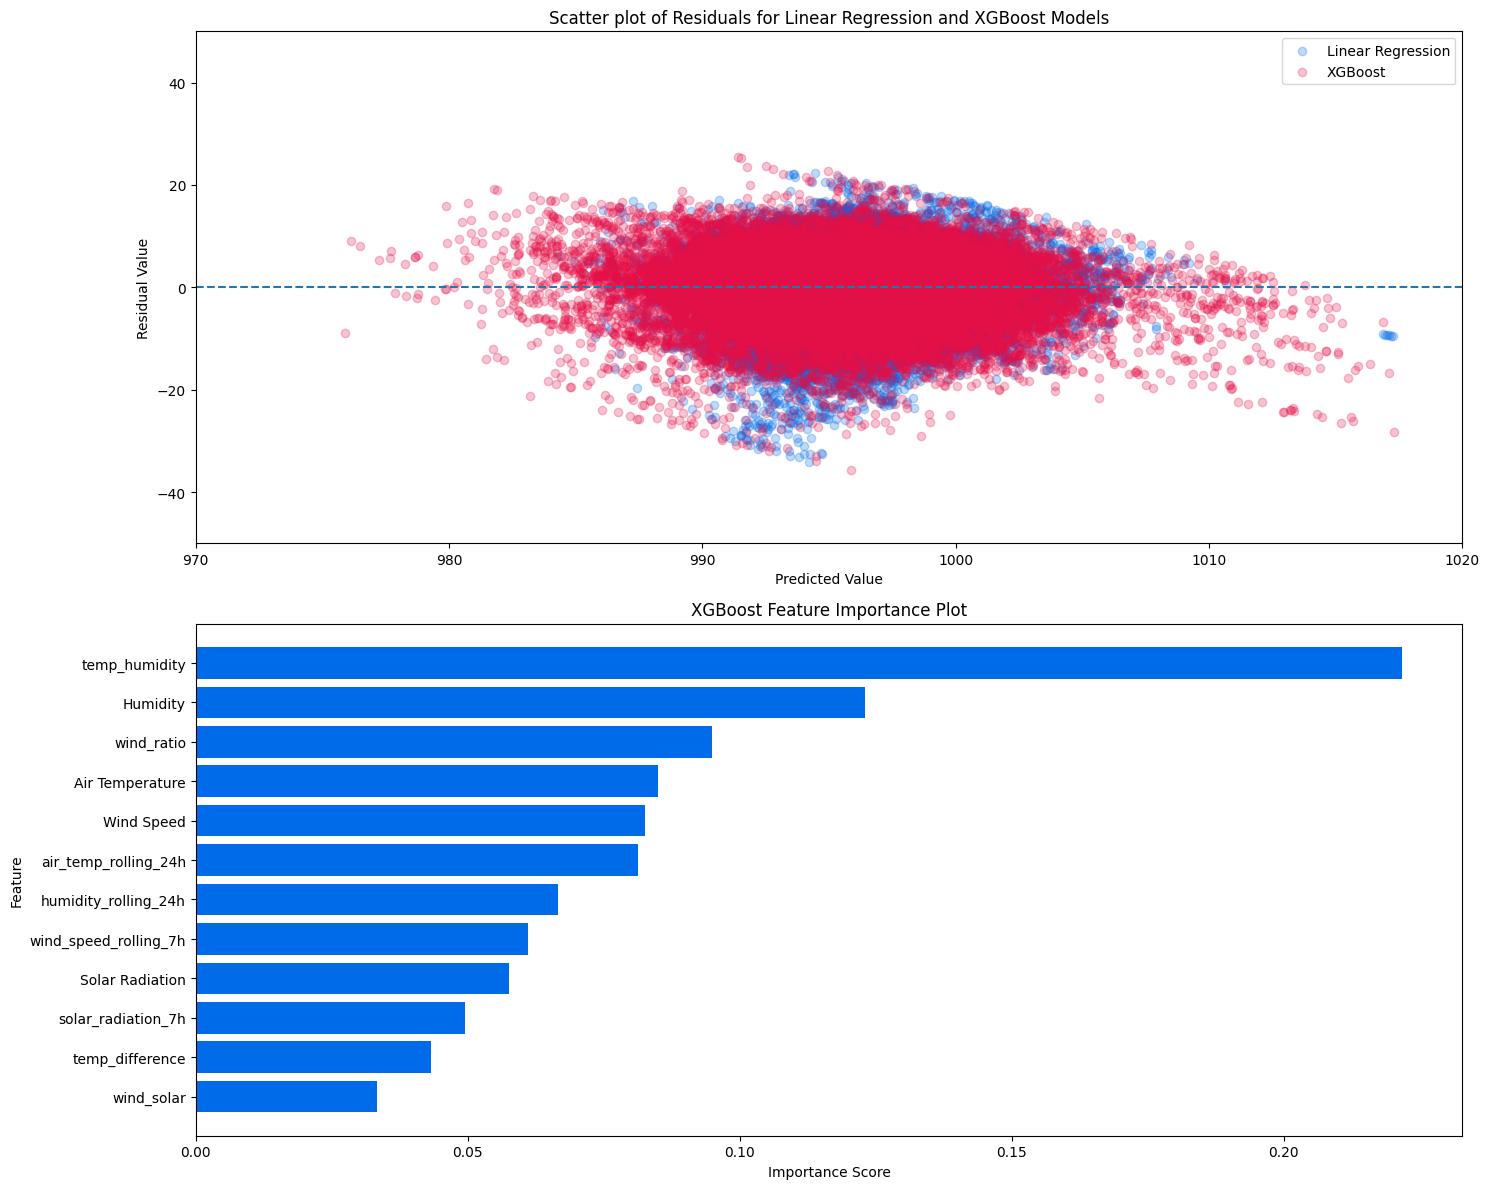

In [42]:
# 1. `output/q8_final_visualizations.png`

# Plot Set-up
fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize=(15, 12))

# Calculate Residuals for Both Models
lr_residuals = predictions['actual'] - predictions['predicted_linear']
xgb_residuals = predictions['actual'] - predictions['predicted_xgboost']

# Scatter plot
axes[0].scatter(
    x = predictions['predicted_linear'], 
    y = lr_residuals,
    color = '#006BE9',
    label = 'Linear Regression',
    alpha = 0.25
    )
axes[0].scatter(
    x = predictions['predicted_xgboost'],
    y = xgb_residuals,
    color = '#E61048',
    label = 'XGBoost',
    alpha = 0.25
)
axes[0].set_xlim(970, 1020)
axes[0].set_ylim(-50, 50)
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Residual Value')
axes[0].set_title('Scatter plot of Residuals for Linear Regression and XGBoost Models')
axes[0].axhline(y = 0, linestyle = '--')
axes[0].legend()

# XGBoost Feature Importance 
features_flipped = feature_importance.sort_values('importance', ascending = True)
axes[1].barh(
    y = features_flipped['feature'],
    width = features_flipped['importance'],
    color = '#006BE9'
)
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Feature')
axes[1].set_title('XGBoost Feature Importance Plot')

# Output q8_final_visualizations.png
plt.tight_layout()
plt.savefig('output/q8_final_visualizations.png', dpi = 300, bbox_inches = 'tight')

In [43]:
# 2. `output/q8_summary.csv`

# Split Metrics By Row
line = metrics.split('\n')

# Select Rows Containing Test Information
test_line = [tline for tline in line if 'Test' in tline]

# Create Dictionary of Relevant Metrics
metrics_comp = {
    'Metric' : ['R²', 'RMSE', 'MAE'],
    'Linear Regression' : [
        float(test_line[0].split(': ')[1]),
        float(test_line[1].split(': ')[1]),
        float(test_line[2].split(': ')[1])
        ],
    'XGBoost' : [
        float(test_line[3].split(': ')[1]),
        float(test_line[4].split(': ')[1]),
        float(test_line[5].split(': ')[1])
    ]
}

# Convert Dictionary to DataFrame
metrics_df = pd.DataFrame(metrics_comp)

# Output q8_summary.csv
metrics_df.to_csv('output/q8_summary.csv', index = False)

In [44]:
# 3. `output/q8_key_findings.txt`
with open('output/q8_key_findings.txt', 'w') as f:
    f.write('KEY FINDINGS SUMMARY\n')
    f.write('===================\n\n')

    f.write('MODEL PERFORMANCE:\n')
    f.write('- Best performing model: XGBoost (R² = 0.2305)\n')
    f.write('- Both models show poor performance (R² < 0.30)\n')
    f.write('- RMSE (6.17 hPa) and MAE (4.77 hPa) for XGBoost is too large for reliable use as a predictive model (3 times larger than daily cycle)\n\n')

    f.write('FEATURE IMPORTANCE:\n')
    f.write('- Most important feature: temp_humidity (importance: 0.2218)\n')
    f.write('- Top 3 features make up 44% of importance\n')
    f.write('- Feature importance is evenly spread out: 8 features have importance between 0.05-0.10\n')
    f.write('- Temporal features appear less important, on average, than base features\n\n')

    f.write('TEMPORAL PATTERNS:\n')
    f.write('Clear yearly-decline in barometric pressure\n')
    f.write('Hourly barometric pressure fluctuates between 994-996 hPa\n\n')

    f.write('DATA QUALITY:\n')
    f.write('Dataset Reduced: 196,555 → 120,365 rows (61.1%)\n')
    f.write('Sites appear to mix recording methods for missing/outlier values\n')
    f.write('Missing/unusual values handled primarily via forward-fill')


---

## Objective

Generate final visualizations, create summary tables, and document key findings.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q8_final_visualizations.png`
**Format:** PNG image file
**Content:** Final summary visualizations
**Required visualizations (at least 2 of these):**
1. **Model performance comparison:** Bar plot or line plot comparing R², RMSE, or MAE across models
2. **Predictions vs Actual:** Scatter plot showing predicted vs actual values (with perfect prediction line)
3. **Feature importance:** Bar plot showing top N features by importance
4. **Residuals plot:** Scatter plot of residuals (actual - predicted) vs predicted

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

### 2. `output/q8_summary.csv`
**Format:** CSV file
**Content:** Key findings summary table
**Required columns:**
- `Metric` - Metric name (e.g., "R² Score", "RMSE", "MAE")
- One column per model (e.g., `Linear Regression`, `Random Forest`, `XGBoost`)

**Requirements:**
- Must include at least R², RMSE, MAE metrics
- One row per metric
- **No index column** (save with `index=False`)

**Example:**
```csv
Metric,Linear Regression,Random Forest,XGBoost
R² Score,-0.0201,0.9705,0.9967
RMSE,12.7154,2.1634,0.7276
MAE,9.8468,1.3545,0.4480
```

### 3. `output/q8_key_findings.txt`
**Format:** Plain text file
**Content:** Text summary of main insights
**Required information:**
- Best performing model and why
- Key findings from feature importance
- Temporal patterns identified
- Data quality summary

**Example format:**
```
KEY FINDINGS SUMMARY
===================

MODEL PERFORMANCE:
- Best performing model: XGBoost (R² = 0.9967)
- All models show reasonable performance (R² > 0.7 for tree-based models)
- XGBoost achieves lowest RMSE: 0.73°C

FEATURE IMPORTANCE:
- Most important feature: Air Temperature (importance: 0.6539)
- Top 3 features account for 93.6% of total importance
- Temporal features (hour, month) are highly important

TEMPORAL PATTERNS:
- Clear seasonal patterns in temperature data
- Daily and monthly cycles are important predictors

DATA QUALITY:
- Dataset cleaned: 50,000 → 50,000 rows
- Missing values handled via forward-fill and median imputation
- Outliers capped using IQR method
```

---

## Requirements Checklist

- [ ] Final visualizations created (model performance, key insights)
- [ ] Summary tables generated
- [ ] Key findings documented
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Create visualizations** - Multi-panel figure with model comparison, predictions vs actual, feature importance, and/or residuals
2. **Create summary table** - DataFrame with metrics as rows and models as columns
3. **Document key findings** - Text summary covering model performance, feature importance insights, temporal patterns, and data quality notes

---

## Decision Points

- **Visualizations:** What best communicates your findings? Model performance plots? Time series with predictions? Feature importance plots?
- **Summary:** What are the key takeaways? Document the most important findings from your analysis.

---

## Checkpoint

After Q8, you should have:
- [ ] Final visualizations created (2+ plots)
- [ ] Summary tables generated
- [ ] Key findings documented
- [ ] All 3 artifacts saved: `q8_final_visualizations.png`, `q8_summary.csv`, `q8_key_findings.txt`

---

**Next:** Continue to `q9_writeup.md` for Writeup.
